In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.13M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/1.41M [00:00<?, ?B/s]

...

Generating jpeg_compression split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/2700 [00:00<?, ? examples/s]


Total images loaded: 21600
Classes: ['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']



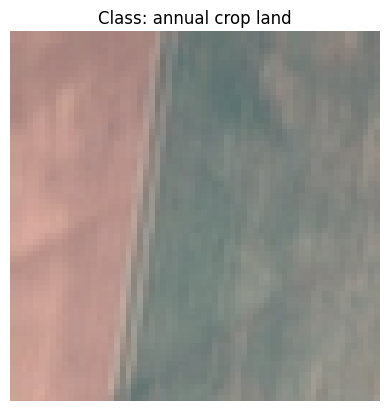

In [1]:

# Install the standard Deep Learning and Hugging Face libraries
!pip install -q transformers datasets evaluate

from datasets import load_dataset
import matplotlib.pyplot as plt

# 1. Load the EuroSAT dataset directly from Hugging Face's cloud
print("Downloading EuroSAT dataset...")
dataset = load_dataset("tanganke/eurosat", split="train")

# 2. Check the land-use classes
labels = dataset.features['label'].names
print(f"\nTotal images loaded: {len(dataset)}")
print(f"Classes: {labels}\n")

# 3. Display a random satellite image to see what the AI will look at!
sample = dataset[42] # Feel free to change this number to see different images
img = sample['image']
label_name = labels[sample['label']]

plt.imshow(img)
plt.title(f"Class: {label_name}")
plt.axis('off')
plt.show()

In [2]:
from transformers import AutoImageProcessor
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

# 1. Split our dataset into Training (80%) and Validation (20%)
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_ds = dataset_split['train']
val_ds = dataset_split['test']

# 2. Load Google's standard Vision Transformer image processor
model_checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

# 3. Create a pipeline to resize, convert to numbers (tensors), and normalize colors
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
transform_pipeline = Compose([
    Resize((224, 224)),
    ToTensor(),
    normalize
])

# 4. Define a function to apply this pipeline to our images
def process_images(examples):
    examples['pixel_values'] = [transform_pipeline(img.convert("RGB")) for img in examples['image']]
    return examples

# 5. Tell the datasets to apply these transformations on-the-fly!
train_ds.set_transform(process_images)
val_ds.set_transform(process_images)

print("Data is split and ready for the Transformer!")
print(f"Training images: {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")
print(f"Neural Network Input Shape: {train_ds[0]['pixel_values'].shape}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Data is split and ready for the Transformer!
Training images: 17280
Validation images: 4320
Neural Network Input Shape: torch.Size([3, 224, 224])


In [7]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
from transformers import DefaultDataCollator
import evaluate
import numpy as np

# 1. Process Images (Returning ONLY the numbers, leaving the raw JPEGs behind)
def process_images(examples):
    pixel_values = [transform_pipeline(img.convert("RGB")) for img in examples['image']]
    return {"pixel_values": pixel_values, "labels": examples['label']}

train_ds.set_transform(process_images)
val_ds.set_transform(process_images)

# 2. Map the labels to IDs
id2label = {id: label for id, label in enumerate(labels)}
label2id = {label: id for id, label in enumerate(labels)}

# 3. Load the Pre-trained Vision Transformer model
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True 
)

# 4. Define how we will measure success
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, true_labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=true_labels)

# 5. Set up the Training Arguments
training_args = TrainingArguments(
    output_dir="./eurosat-vit-model",
    remove_unused_columns=False,   # <--- FIX: Back to False so it doesn't delete the images early!
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2, 
    per_device_eval_batch_size=16,
    num_train_epochs=1, 
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none" 
)

# 6. Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DefaultDataCollator(),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# 7. START TRAINING! 🚀
print("Starting the training process... Grab a coffee, this will take a few minutes!")
trainer.train()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting the training process... Grab a coffee, this will take a few minutes!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.277078,0.262112,0.980556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=270, training_loss=0.5909956313945629, metrics={'train_runtime': 401.2876, 'train_samples_per_second': 43.061, 'train_steps_per_second': 0.673, 'total_flos': 1.3391575932233318e+18, 'train_loss': 0.5909956313945629, 'epoch': 1.0})

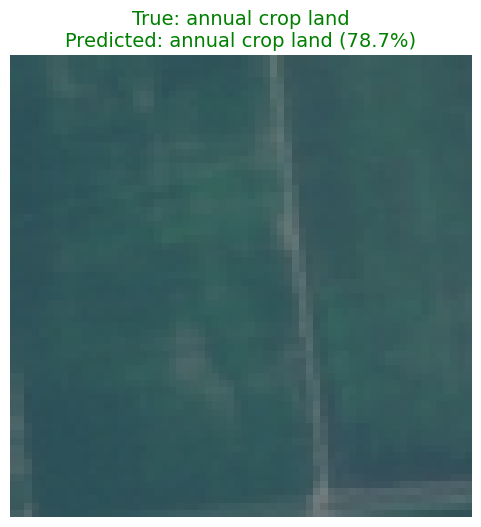

In [9]:
import torch
import random
import matplotlib.pyplot as plt

# 1. Pick a random image from the ORIGINAL dataset (which still has the raw images!)
random_idx = random.randint(0, len(dataset) - 1)
raw_sample = dataset[random_idx]
raw_image = raw_sample['image']
true_label = labels[raw_sample['label']]

# 2. Process the image so the model can understand it
inputs = image_processor(raw_image, return_tensors="pt")
# Move the image to the GPU (where our model currently lives)
inputs = {k: v.to(trainer.args.device) for k, v in inputs.items()}

# 3. Make a Prediction!
model.eval() # Put the model into testing mode
with torch.no_grad():
    outputs = model(**inputs)
    
    # Get the highest probability score
    predicted_id = outputs.logits.argmax(-1).item()
    predicted_label = id2label[predicted_id]
    
    # Calculate confidence percentage
    confidence = torch.nn.functional.softmax(outputs.logits, dim=-1)[0, predicted_id].item()

# 4. Display the result
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)

# Make the title green if it got it right, red if it got it wrong
color = "green" if true_label == predicted_label else "red"
plt.title(f"True: {true_label}\nPredicted: {predicted_label} ({confidence*100:.1f}%)", color=color, fontsize=14)
plt.axis('off')
plt.show()